### Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.dummy import DummyClassifier

RANDOM_STATE = 42

# Store all experiment results
experiment_results = []

In [2]:
train_df = pd.read_csv("train_final.csv")
test_df = pd.read_csv("test_final.csv")
validation_df = pd.read_csv("validation_final.csv")

### Prepare X / Y

In [3]:
# Split features and target
X_train = train_df.drop(columns="y")
y_train = train_df["y"]

X_val = validation_df.drop(columns="y")
y_val = validation_df["y"]

X_test = test_df.drop(columns="y")
y_test = test_df["y"]

# Get class labels
class_labels = sorted(y_train.unique())

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Classes:", class_labels)

Train shape: (69864, 25)
Validation shape: (14952, 25)
Test shape: (14954, 25)
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### Evaluation Utilities

In [4]:
def evaluate_model(model, X, y, model_name, variant, show_confusion=True):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    balanced_acc = balanced_accuracy_score(y, y_pred)
    macro_f1 = f1_score(y, y_pred, average="macro")
    weighted_f1 = f1_score(y, y_pred, average="weighted")

    result = {
        "Model": model_name,
        "Variant": variant,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Balanced Accuracy": balanced_acc,
        "Accuracy": accuracy
    }

    experiment_results.append(result)

    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Weighted F1:       {weighted_f1:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Accuracy:           {accuracy:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y,
            y_pred,
            labels=class_labels,
            zero_division=0
        )
    )

    if show_confusion:
        cm = confusion_matrix(
            y,
            y_pred,
            labels=class_labels
        )

        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_labels
        ).plot(cmap="Blues")

        plt.title(f"{model_name} - {variant}")
        plt.show()

    return y_pred

## Dummy Baseline

Macro F1:          0.2216
Weighted F1:       0.7052
Balanced Accuracy: 0.2500
Accuracy:           0.7957

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       131
           2       0.80      1.00      0.89     11898
           3       0.00      0.00      0.00      2530
           4       0.00      0.00      0.00       393

    accuracy                           0.80     14952
   macro avg       0.20      0.25      0.22     14952
weighted avg       0.63      0.80      0.71     14952



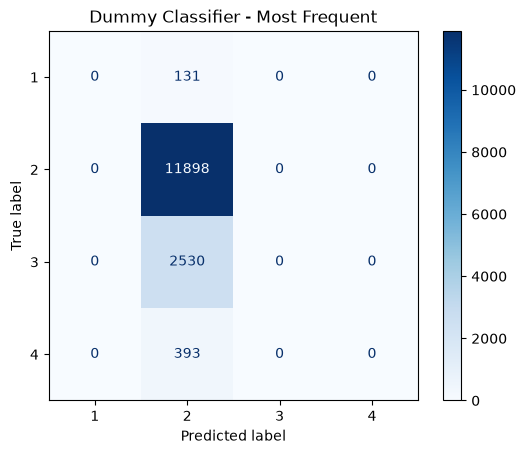

In [5]:
# Train dummy baseline
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

dummy_model.fit(X_train, y_train)

# Evaluate on validation set
dummy_val_pred = evaluate_model(
    model=dummy_model,
    X=X_val,
    y=y_val,
    model_name="Dummy Classifier",
    variant="Most Frequent"
)

We used `most_frequent` as the strategy for the Dummy Model, meaning that it always predicts the most common target class.

Because the dataset is highly imbalanced, this provides a useful baseline for showing why Accuracy alone can be misleading. A model may achieve relatively high Accuracy simply by predicting the majority class, while performing poorly on the minority classes.

## Multinomial Logistic Regression

### Logistic Regression Baseline

Macro F1:          0.4817
Weighted F1:       0.8346
Balanced Accuracy: 0.4518
Accuracy:           0.8492

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       131
           2       0.87      0.95      0.91     11898
           3       0.72      0.49      0.58      2530
           4       0.53      0.36      0.43       393

    accuracy                           0.85     14952
   macro avg       0.53      0.45      0.48     14952
weighted avg       0.83      0.85      0.83     14952



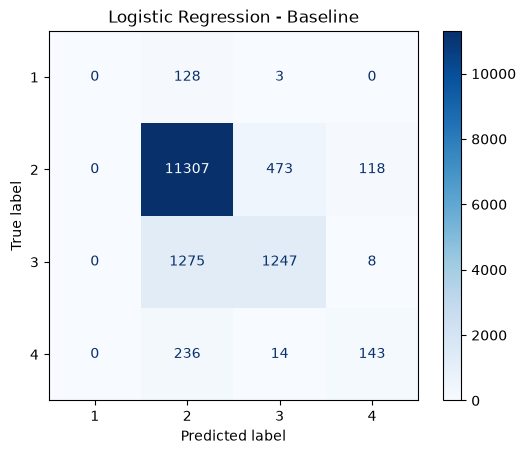

In [6]:
from sklearn.linear_model import LogisticRegression

# Train baseline model
lr_base = LogisticRegression(
    solver="lbfgs",
    # penalty="l2",
    C=1.0,
    max_iter=3000,
    random_state=RANDOM_STATE
)

lr_base.fit(X_train, y_train)

# Evaluate on validation set
lr_base_val_pred = evaluate_model(
    model=lr_base,
    X=X_val,
    y=y_val,
    model_name="Logistic Regression",
    variant="Baseline"
)

### Balanced Logistic Regression

Macro F1:          0.4573
Weighted F1:       0.6701
Balanced Accuracy: 0.7232
Accuracy:           0.5914

Classification Report:
              precision    recall  f1-score   support

           1       0.03      0.73      0.05       131
           2       0.95      0.55      0.70     11898
           3       0.52      0.74      0.61      2530
           4       0.32      0.88      0.47       393

    accuracy                           0.59     14952
   macro avg       0.45      0.72      0.46     14952
weighted avg       0.85      0.59      0.67     14952



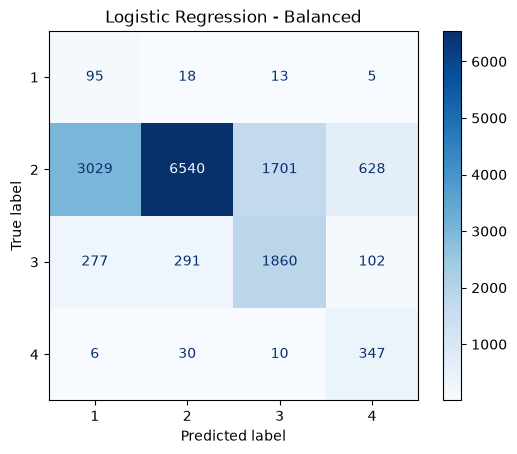

In [7]:
# Train balanced model
lr_balanced = LogisticRegression(
    solver="lbfgs",
    # penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=3000,
    random_state=RANDOM_STATE
)

lr_balanced.fit(X_train, y_train)

# Evaluate on validation set
lr_balanced_val_pred = evaluate_model(
    model=lr_balanced,
    X=X_val,
    y=y_val,
    model_name="Logistic Regression",
    variant="Balanced"
)

### Hyperparameter Tuning

In [8]:
# Define search space
lr_c_values = [0.01, 0.1, 0.5, 1.0, 2.0, 10.0, 100.0]
lr_class_weights = [None, "balanced"]

lr_tuning_results = []

# Test parameter combinations
for c_value in lr_c_values:
    for weight in lr_class_weights:

        model = LogisticRegression(
            solver="lbfgs",
            # penalty="l2",
            C=c_value,
            class_weight=weight,
            max_iter=3000,
            random_state=RANDOM_STATE
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        lr_tuning_results.append({
            "C": c_value,
            "Class Weight": weight,
            "Macro F1": f1_score(y_val, y_pred, average="macro"),
            "Weighted F1": f1_score(y_val, y_pred, average="weighted"),
            "Balanced Accuracy": balanced_accuracy_score(y_val, y_pred),
            "Accuracy": accuracy_score(y_val, y_pred)
        })

# Create tuning table
lr_tuning_df = pd.DataFrame(lr_tuning_results)

lr_tuning_df = lr_tuning_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

lr_tuning_df

,C,Class Weight,Macro F1,Weighted F1,Balanced Accuracy,Accuracy
0,100.00,NaN,0.483125,0.835105,0.453438,0.849585
1,2.00,NaN,0.482749,0.834614,0.452923,0.849184
2,0.50,NaN,0.482329,0.834811,0.451932,0.849452
3,10.00,NaN,0.482297,0.834785,0.452583,0.849318
4,1.00,NaN,0.481687,0.834575,0.451770,0.849184
5,0.10,NaN,0.479520,0.834014,0.448759,0.848917
6,0.01,NaN,0.461394,0.830313,0.425811,0.847713
7,1.00,balanced,0.457312,0.670105,0.723248,0.591359
8,2.00,balanced,0.457225,0.670020,0.723149,0.591292
9,100.00,balanced,0.457225,0.669981,0.723128,0.591225


### Select Best Logistic Regression

Best C: 100.0
Best Class Weight: None
Best Validation Macro F1: 0.4831
Macro F1:          0.4831
Weighted F1:       0.8351
Balanced Accuracy: 0.4534
Accuracy:           0.8496

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       131
           2       0.87      0.95      0.91     11898
           3       0.72      0.49      0.59      2530
           4       0.53      0.37      0.44       393

    accuracy                           0.85     14952
   macro avg       0.53      0.45      0.48     14952
weighted avg       0.83      0.85      0.84     14952



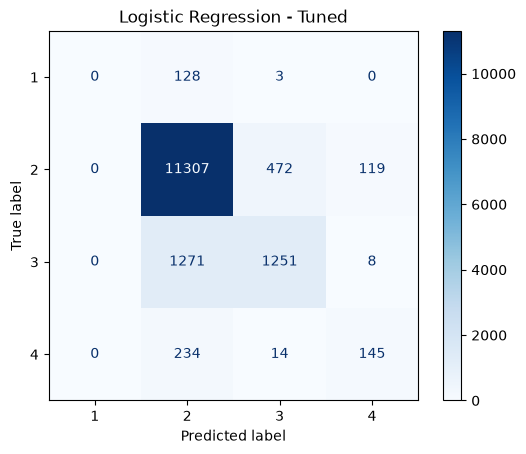

In [9]:
# Get best parameters
best_lr_row = lr_tuning_df.iloc[0]

best_lr_c = best_lr_row["C"]
best_lr_weight = best_lr_row["Class Weight"]

# Convert missing value back to None
if pd.isna(best_lr_weight):
    best_lr_weight = None

print("Best C:", best_lr_c)
print("Best Class Weight:", best_lr_weight)
print("Best Validation Macro F1:", round(best_lr_row["Macro F1"], 4))

# Train best logistic regression
best_lr_model = LogisticRegression(
    solver="lbfgs",
    # penalty="l2",
    C=best_lr_c,
    class_weight=best_lr_weight,
    max_iter=3000,
    random_state=RANDOM_STATE
)

best_lr_model.fit(X_train, y_train)

# Final validation evaluation
best_lr_val_pred = evaluate_model(
    model=best_lr_model,
    X=X_val,
    y=y_val,
    model_name="Logistic Regression",
    variant="Tuned"
)

## Random Forest Classifier

### Random Forest Baseline

Macro F1:          0.5504
Weighted F1:       0.8585
Balanced Accuracy: 0.4894
Accuracy:           0.8703

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.08      0.15       131
           2       0.89      0.96      0.92     11898
           3       0.75      0.58      0.65      2530
           4       0.78      0.34      0.47       393

    accuracy                           0.87     14952
   macro avg       0.85      0.49      0.55     14952
weighted avg       0.86      0.87      0.86     14952



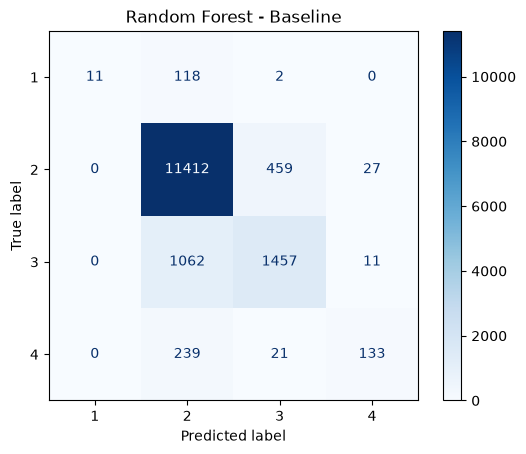

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Train baseline model
rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

# Evaluate on validation set
rf_base_val_pred = evaluate_model(
    model=rf_base,
    X=X_val,
    y=y_val,
    model_name="Random Forest",
    variant="Baseline"
)

### Balanced Random Forest

Macro F1:          0.5820
Weighted F1:       0.8510
Balanced Accuracy: 0.6174
Accuracy:           0.8462

Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.11      0.18       131
           2       0.94      0.87      0.90     11898
           3       0.61      0.78      0.69      2530
           4       0.46      0.71      0.56       393

    accuracy                           0.85     14952
   macro avg       0.64      0.62      0.58     14952
weighted avg       0.86      0.85      0.85     14952



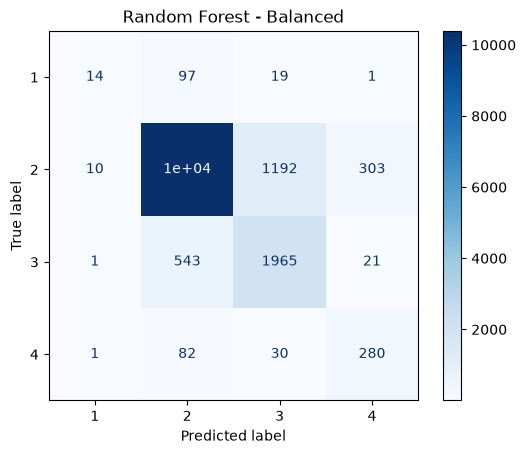

In [11]:
# Train balanced model
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

# Evaluate on validation set
rf_balanced_val_pred = evaluate_model(
    model=rf_balanced,
    X=X_val,
    y=y_val,
    model_name="Random Forest",
    variant="Balanced"
)

### Hyperparameter Tuning

In [12]:
from sklearn.model_selection import ParameterSampler

# Define search space
rf_param_space = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 15, 25, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

# Sample parameter combinations
rf_param_samples = list(
    ParameterSampler(
        rf_param_space,
        n_iter=24,
        random_state=RANDOM_STATE
    )
)

rf_tuning_results = []

# Test parameter combinations
for i, params in enumerate(rf_param_samples, start=1):

    model = RandomForestClassifier(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    rf_tuning_results.append({
        **params,
        "Macro F1": f1_score(y_val, y_pred, average="macro"),
        "Weighted F1": f1_score(y_val, y_pred, average="weighted"),
        "Balanced Accuracy": balanced_accuracy_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred)
    })

    print(
        f"{i}/{len(rf_param_samples)} - "
        f"Macro F1: {rf_tuning_results[-1]['Macro F1']:.4f}"
    )

# Create tuning table
rf_tuning_df = pd.DataFrame(rf_tuning_results)

rf_tuning_df = rf_tuning_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

rf_tuning_df

1/24 - Macro F1: 0.5629
2/24 - Macro F1: 0.5618
3/24 - Macro F1: 0.5837
4/24 - Macro F1: 0.5459
5/24 - Macro F1: 0.5768
6/24 - Macro F1: 0.5623
7/24 - Macro F1: 0.5404
8/24 - Macro F1: 0.5428
9/24 - Macro F1: 0.5905
10/24 - Macro F1: 0.5904
11/24 - Macro F1: 0.5895
12/24 - Macro F1: 0.5674
13/24 - Macro F1: 0.5646
14/24 - Macro F1: 0.5464
15/24 - Macro F1: 0.5661
16/24 - Macro F1: 0.5443
17/24 - Macro F1: 0.5911
18/24 - Macro F1: 0.5405
19/24 - Macro F1: 0.5658
20/24 - Macro F1: 0.5704
21/24 - Macro F1: 0.5357
22/24 - Macro F1: 0.5707
23/24 - Macro F1: 0.5465
24/24 - Macro F1: 0.5381


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,class_weight,Macro F1,Weighted F1,Balanced Accuracy,Accuracy
0,200,2,4,0.5,NaN,balanced_subsample,0.591134,0.859728,0.598324,0.859283
1,300,5,4,0.5,40.0,balanced_subsample,0.590539,0.859279,0.599075,0.858748
2,300,10,4,0.5,25.0,balanced_subsample,0.590446,0.856319,0.613548,0.854066
3,500,5,2,0.5,25.0,balanced,0.589518,0.841413,0.681473,0.830257
4,200,2,4,log2,25.0,balanced_subsample,0.583665,0.851024,0.627509,0.846576
5,500,5,4,0.5,40.0,balanced,0.576787,0.831681,0.696041,0.817014
6,200,5,2,0.5,40.0,NaN,0.570731,0.861906,0.508033,0.872057
7,300,2,2,0.5,40.0,NaN,0.570410,0.860548,0.507025,0.870853
8,200,5,1,0.5,25.0,balanced_subsample,0.567389,0.855404,0.554390,0.859617
9,200,5,2,0.5,NaN,balanced_subsample,0.566054,0.860823,0.528060,0.867242


### Select Best Random Forest

Best n_estimators: 200
Best max_depth: None
Best min_samples_split: 2
Best min_samples_leaf: 4
Best max_features: 0.5
Best class_weight: balanced_subsample
Best Validation Macro F1: 0.5911
Macro F1:          0.5911
Weighted F1:       0.8597
Balanced Accuracy: 0.5983
Accuracy:           0.8593

Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.13      0.21       131
           2       0.92      0.91      0.91     11898
           3       0.67      0.71      0.69      2530
           4       0.48      0.65      0.55       393

    accuracy                           0.86     14952
   macro avg       0.65      0.60      0.59     14952
weighted avg       0.86      0.86      0.86     14952



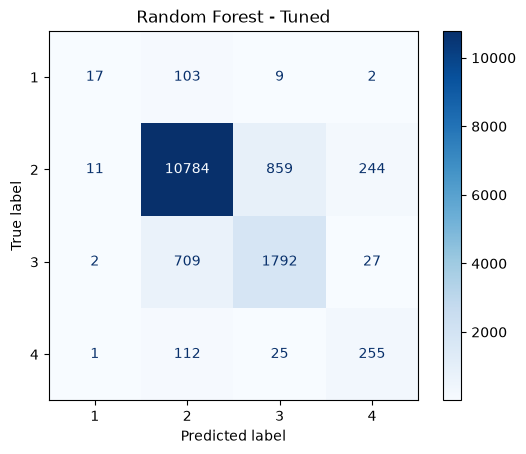

In [13]:
# Get best parameters
best_rf_row = rf_tuning_df.iloc[0]

best_rf_n_estimators = int(best_rf_row["n_estimators"])

best_rf_max_depth = best_rf_row["max_depth"]
if pd.isna(best_rf_max_depth):
    best_rf_max_depth = None
else:
    best_rf_max_depth = int(best_rf_max_depth)

best_rf_min_samples_split = int(best_rf_row["min_samples_split"])
best_rf_min_samples_leaf = int(best_rf_row["min_samples_leaf"])

best_rf_max_features = best_rf_row["max_features"]

best_rf_weight = best_rf_row["class_weight"]
if pd.isna(best_rf_weight):
    best_rf_weight = None

print("Best n_estimators:", best_rf_n_estimators)
print("Best max_depth:", best_rf_max_depth)
print("Best min_samples_split:", best_rf_min_samples_split)
print("Best min_samples_leaf:", best_rf_min_samples_leaf)
print("Best max_features:", best_rf_max_features)
print("Best class_weight:", best_rf_weight)
print("Best Validation Macro F1:", round(best_rf_row["Macro F1"], 4))

# Train best random forest
best_rf_model = RandomForestClassifier(
    n_estimators=best_rf_n_estimators,
    max_depth=best_rf_max_depth,
    min_samples_split=best_rf_min_samples_split,
    min_samples_leaf=best_rf_min_samples_leaf,
    max_features=best_rf_max_features,
    class_weight=best_rf_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_rf_model.fit(X_train, y_train)

# Final validation evaluation
best_rf_val_pred = evaluate_model(
    model=best_rf_model,
    X=X_val,
    y=y_val,
    model_name="Random Forest",
    variant="Tuned"
)

## XGBoost

### XGBoost Baseline

Macro F1:          0.5837
Weighted F1:       0.8622
Balanced Accuracy: 0.5227
Accuracy:           0.8718

Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.14      0.24       131
           2       0.89      0.96      0.92     11898
           3       0.75      0.59      0.66      2530
           4       0.69      0.41      0.51       393

    accuracy                           0.87     14952
   macro avg       0.80      0.52      0.58     14952
weighted avg       0.86      0.87      0.86     14952



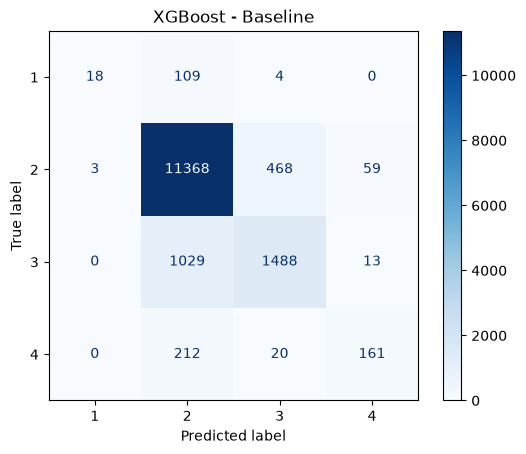

In [14]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight


class EncodedXGBClassifier:
    def __init__(self, **params):
        self.params = params
        self.model = XGBClassifier(**params)
        self.label_encoder = LabelEncoder()

    def fit(self, X, y, sample_weight=None):
        y_encoded = self.label_encoder.fit_transform(y)

        self.model.fit(
            X,
            y_encoded,
            sample_weight=sample_weight
        )

        return self

    def predict(self, X):
        y_pred_encoded = self.model.predict(X).astype(int)

        return self.label_encoder.inverse_transform(
            y_pred_encoded
        )


# Train baseline model
xgb_base = EncodedXGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softprob",
    num_class=len(class_labels),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_base.fit(X_train, y_train)

# Evaluate on validation set
xgb_base_val_pred = evaluate_model(
    model=xgb_base,
    X=X_val,
    y=y_val,
    model_name="XGBoost",
    variant="Baseline"
)

### Weighted XGBoost

Macro F1:          0.5591
Weighted F1:       0.8185
Balanced Accuracy: 0.7160
Accuracy:           0.7960

Classification Report:
              precision    recall  f1-score   support

           1       0.09      0.43      0.15       131
           2       0.95      0.80      0.87     11898
           3       0.57      0.81      0.67      2530
           4       0.41      0.83      0.55       393

    accuracy                           0.80     14952
   macro avg       0.51      0.72      0.56     14952
weighted avg       0.86      0.80      0.82     14952



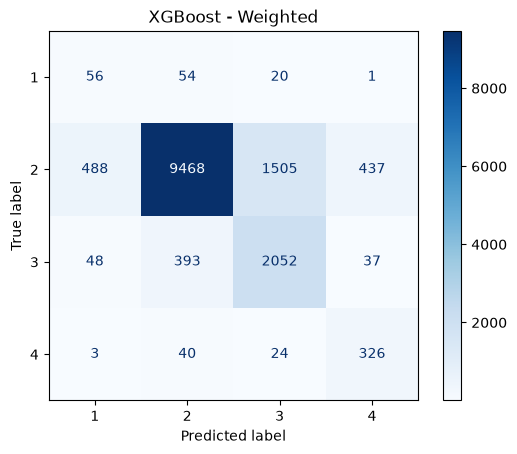

In [15]:
# Create balanced sample weights
xgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Train weighted model
xgb_weighted = EncodedXGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softprob",
    num_class=len(class_labels),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_weighted.fit(
    X_train,
    y_train,
    sample_weight=xgb_sample_weights
)

# Evaluate on validation set
xgb_weighted_val_pred = evaluate_model(
    model=xgb_weighted,
    X=X_val,
    y=y_val,
    model_name="XGBoost",
    variant="Weighted"
)

### XGBoost Hyperparameter Tuning

In [16]:
# Define search space
xgb_param_space = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10],
    "use_weights": [False, True]
}

# Sample parameter combinations
xgb_param_samples = list(
    ParameterSampler(
        xgb_param_space,
        n_iter=24,
        random_state=RANDOM_STATE
    )
)

xgb_tuning_results = []

# Test parameter combinations
for i, params in enumerate(xgb_param_samples, start=1):

    params = params.copy()

    use_weights = params.pop("use_weights")

    model = EncodedXGBClassifier(
        **params,
        objective="multi:softprob",
        num_class=len(class_labels),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    sample_weights = (
        xgb_sample_weights
        if use_weights
        else None
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights
    )

    y_pred = model.predict(X_val)

    xgb_tuning_results.append({
        **params,
        "Use Weights": use_weights,
        "Macro F1": f1_score(
            y_val,
            y_pred,
            average="macro"
        ),
        "Weighted F1": f1_score(
            y_val,
            y_pred,
            average="weighted"
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_val,
            y_pred
        ),
        "Accuracy": accuracy_score(
            y_val,
            y_pred
        )
    })

    print(
        f"{i}/{len(xgb_param_samples)} - "
        f"Macro F1: "
        f"{xgb_tuning_results[-1]['Macro F1']:.4f}"
    )


# Create tuning table
xgb_tuning_df = pd.DataFrame(
    xgb_tuning_results
)

xgb_tuning_df = xgb_tuning_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

xgb_tuning_df

1/24 - Macro F1: 0.5166
2/24 - Macro F1: 0.5513
3/24 - Macro F1: 0.5691
4/24 - Macro F1: 0.5452
5/24 - Macro F1: 0.5703
6/24 - Macro F1: 0.5068
7/24 - Macro F1: 0.5760
8/24 - Macro F1: 0.5411
9/24 - Macro F1: 0.5725
10/24 - Macro F1: 0.5111
11/24 - Macro F1: 0.5628
12/24 - Macro F1: 0.5253
13/24 - Macro F1: 0.5346
14/24 - Macro F1: 0.5721
15/24 - Macro F1: 0.5284
16/24 - Macro F1: 0.5194
17/24 - Macro F1: 0.5860
18/24 - Macro F1: 0.5395
19/24 - Macro F1: 0.5655
20/24 - Macro F1: 0.5305
21/24 - Macro F1: 0.5013
22/24 - Macro F1: 0.5942
23/24 - Macro F1: 0.5594
24/24 - Macro F1: 0.5590


,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,Use Weights,Macro F1,Weighted F1,Balanced Accuracy,Accuracy
0,0.70,1,0.1,200,1,9,0.10,0.1,0.85,True,0.594159,0.851818,0.645624,0.845171
1,0.70,1,0.1,600,5,7,0.10,0.0,0.70,True,0.585959,0.849174,0.635558,0.842429
2,0.85,1,0.0,200,5,7,0.10,0.3,0.70,False,0.575957,0.860956,0.516442,0.870720
3,0.85,1,1.0,400,1,5,0.10,0.0,0.85,False,0.572548,0.862544,0.515682,0.872325
4,1.00,5,0.0,400,3,9,0.03,0.0,0.70,True,0.572100,0.825445,0.736674,0.804106
5,1.00,10,1.0,400,1,9,0.10,0.1,0.70,False,0.570288,0.862781,0.511651,0.872860
6,1.00,10,0.1,400,3,7,0.05,0.0,1.00,False,0.569137,0.861698,0.511739,0.871656
7,0.85,1,1.0,600,3,3,0.10,0.0,1.00,False,0.565486,0.859972,0.508122,0.870385
8,0.70,10,0.0,400,5,7,0.05,0.1,1.00,True,0.562776,0.819071,0.730744,0.797017
9,0.70,5,0.1,400,1,5,0.03,0.1,0.70,False,0.559367,0.859937,0.499516,0.871188


### Select Best XGBoost

Best n_estimators: 200
Best learning_rate: 0.1
Best max_depth: 9
Best min_child_weight: 1.0
Best subsample: 0.7
Best colsample_bytree: 0.85
Best gamma: 0.1
Best reg_alpha: 0.1
Best reg_lambda: 1.0
Use Weights: True
Best Validation Macro F1: 0.5942
Macro F1:          0.5942
Weighted F1:       0.8518
Balanced Accuracy: 0.6456
Accuracy:           0.8452

Classification Report:
              precision    recall  f1-score   support

           1       0.21      0.21      0.21       131
           2       0.94      0.87      0.90     11898
           3       0.62      0.77      0.69      2530
           4       0.47      0.73      0.57       393

    accuracy                           0.85     14952
   macro avg       0.56      0.65      0.59     14952
weighted avg       0.86      0.85      0.85     14952



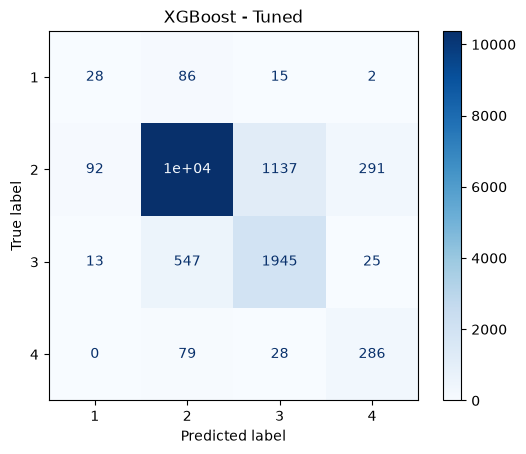

In [17]:
# Get best parameters
best_xgb_row = xgb_tuning_df.iloc[0]

best_xgb_n_estimators = int(
    best_xgb_row["n_estimators"]
)

best_xgb_learning_rate = float(
    best_xgb_row["learning_rate"]
)

best_xgb_max_depth = int(
    best_xgb_row["max_depth"]
)

best_xgb_min_child_weight = float(
    best_xgb_row["min_child_weight"]
)

best_xgb_subsample = float(
    best_xgb_row["subsample"]
)

best_xgb_colsample = float(
    best_xgb_row["colsample_bytree"]
)

best_xgb_gamma = float(
    best_xgb_row["gamma"]
)

best_xgb_reg_alpha = float(
    best_xgb_row["reg_alpha"]
)

best_xgb_reg_lambda = float(
    best_xgb_row["reg_lambda"]
)

best_xgb_use_weights = bool(
    best_xgb_row["Use Weights"]
)


print("Best n_estimators:", best_xgb_n_estimators)
print("Best learning_rate:", best_xgb_learning_rate)
print("Best max_depth:", best_xgb_max_depth)
print("Best min_child_weight:", best_xgb_min_child_weight)
print("Best subsample:", best_xgb_subsample)
print("Best colsample_bytree:", best_xgb_colsample)
print("Best gamma:", best_xgb_gamma)
print("Best reg_alpha:", best_xgb_reg_alpha)
print("Best reg_lambda:", best_xgb_reg_lambda)
print("Use Weights:", best_xgb_use_weights)

print(
    "Best Validation Macro F1:",
    round(best_xgb_row["Macro F1"], 4)
)


# Train best XGBoost model
best_xgb_model = EncodedXGBClassifier(
    n_estimators=best_xgb_n_estimators,
    learning_rate=best_xgb_learning_rate,
    max_depth=best_xgb_max_depth,
    min_child_weight=best_xgb_min_child_weight,
    subsample=best_xgb_subsample,
    colsample_bytree=best_xgb_colsample,
    gamma=best_xgb_gamma,
    reg_alpha=best_xgb_reg_alpha,
    reg_lambda=best_xgb_reg_lambda,
    objective="multi:softprob",
    num_class=len(class_labels),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_xgb_sample_weights = (
    xgb_sample_weights
    if best_xgb_use_weights
    else None
)

best_xgb_model.fit(
    X_train,
    y_train,
    sample_weight=best_xgb_sample_weights
)

# Final validation evaluation
best_xgb_val_pred = evaluate_model(
    model=best_xgb_model,
    X=X_val,
    y=y_val,
    model_name="XGBoost",
    variant="Tuned"
)

## Compare All Experiments

In [18]:
# Create experiment comparison table
results_df = pd.DataFrame(experiment_results)

# Keep latest result if a cell was rerun
results_df = results_df.drop_duplicates(
    subset=["Model", "Variant"],
    keep="last"
)

# Sort by main metric
results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Variant,Macro F1,Weighted F1,Balanced Accuracy,Accuracy
0,XGBoost,Tuned,0.594159,0.851818,0.645624,0.845171
1,Random Forest,Tuned,0.591134,0.859728,0.598324,0.859283
2,XGBoost,Baseline,0.583678,0.862223,0.522668,0.871790
3,Random Forest,Balanced,0.581960,0.850984,0.617382,0.846174
4,XGBoost,Weighted,0.559059,0.818498,0.715957,0.796014
5,Random Forest,Baseline,0.550393,0.858532,0.489358,0.870318
6,Logistic Regression,Tuned,0.483125,0.835105,0.453438,0.849585
7,Logistic Regression,Baseline,0.481687,0.834575,0.451770,0.849184
8,Logistic Regression,Balanced,0.457312,0.670105,0.723248,0.591359
9,Dummy Classifier,Most Frequent,0.221564,0.705236,0.250000,0.795746


## Select Champion Model

In [19]:
# Register candidate models
candidate_models = {
    "LR - Baseline": {
        "model": lr_base,
        "family": "Logistic Regression",
        "variant": "Baseline",
        "use_weights": False
    },
    "LR - Balanced": {
        "model": lr_balanced,
        "family": "Logistic Regression",
        "variant": "Balanced",
        "use_weights": False
    },
    "LR - Tuned": {
        "model": best_lr_model,
        "family": "Logistic Regression",
        "variant": "Tuned",
        "use_weights": False
    },

    "RF - Baseline": {
        "model": rf_base,
        "family": "Random Forest",
        "variant": "Baseline",
        "use_weights": False
    },
    "RF - Balanced": {
        "model": rf_balanced,
        "family": "Random Forest",
        "variant": "Balanced",
        "use_weights": False
    },
    "RF - Tuned": {
        "model": best_rf_model,
        "family": "Random Forest",
        "variant": "Tuned",
        "use_weights": False
    },

    "XGB - Baseline": {
        "model": xgb_base,
        "family": "XGBoost",
        "variant": "Baseline",
        "use_weights": False
    },
    "XGB - Weighted": {
        "model": xgb_weighted,
        "family": "XGBoost",
        "variant": "Weighted",
        "use_weights": True
    },
    "XGB - Tuned": {
        "model": best_xgb_model,
        "family": "XGBoost",
        "variant": "Tuned",
        "use_weights": best_xgb_use_weights
    }
}

candidate_results = []

# Compare candidates on validation set
for candidate_name, info in candidate_models.items():

    y_pred = info["model"].predict(X_val)

    candidate_results.append({
        "Candidate": candidate_name,
        "Model": info["family"],
        "Variant": info["variant"],
        "Macro F1": f1_score(
            y_val,
            y_pred,
            average="macro"
        ),
        "Weighted F1": f1_score(
            y_val,
            y_pred,
            average="weighted"
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_val,
            y_pred
        ),
        "Accuracy": accuracy_score(
            y_val,
            y_pred
        )
    })

# Create comparison table
candidate_comparison_df = pd.DataFrame(
    candidate_results
).sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

# Select champion
champion_key = candidate_comparison_df.iloc[0]["Candidate"]
champion_info = candidate_models[champion_key]

champion_model = champion_info["model"]
champion_family = champion_info["family"]
champion_variant = champion_info["variant"]
champion_use_weights = champion_info["use_weights"]

print("Champion:", champion_key)
print(
    "Validation Macro F1:",
    round(candidate_comparison_df.iloc[0]["Macro F1"], 4)
)

candidate_comparison_df

Champion: XGB - Tuned
Validation Macro F1: 0.5942


,Candidate,Model,Variant,Macro F1,Weighted F1,Balanced Accuracy,Accuracy
0,XGB - Tuned,XGBoost,Tuned,0.594159,0.851818,0.645624,0.845171
1,RF - Tuned,Random Forest,Tuned,0.591134,0.859728,0.598324,0.859283
2,XGB - Baseline,XGBoost,Baseline,0.583678,0.862223,0.522668,0.871790
3,RF - Balanced,Random Forest,Balanced,0.581960,0.850984,0.617382,0.846174
4,XGB - Weighted,XGBoost,Weighted,0.559059,0.818498,0.715957,0.796014
5,RF - Baseline,Random Forest,Baseline,0.550393,0.858532,0.489358,0.870318
6,LR - Tuned,Logistic Regression,Tuned,0.483125,0.835105,0.453438,0.849585
7,LR - Baseline,Logistic Regression,Baseline,0.481687,0.834575,0.451770,0.849184
8,LR - Balanced,Logistic Regression,Balanced,0.457312,0.670105,0.723248,0.591359


## Retrain on Train + Validation

In [20]:
from sklearn.base import clone

# Combine train and validation sets
X_train_final = pd.concat(
    [X_train, X_val],
    axis=0,
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0,
    ignore_index=True
)

# Retrain champion model
if champion_family == "XGBoost":

    final_model = EncodedXGBClassifier(
        **champion_model.params
    )

    if champion_use_weights:
        final_sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train_final
        )
    else:
        final_sample_weights = None

    final_model.fit(
        X_train_final,
        y_train_final,
        sample_weight=final_sample_weights
    )

else:

    final_model = clone(champion_model)

    final_model.fit(
        X_train_final,
        y_train_final
    )


print("Final model:", champion_family)
print("Variant:", champion_variant)
print("Training samples:", len(X_train_final))

Final model: XGBoost
Variant: Tuned
Training samples: 84816


## Final Evaluation on Test

Final Test Results
-----------------------------------
Macro F1:          0.5943
Weighted F1:       0.8439
Balanced Accuracy: 0.6558
Accuracy:          0.8352

Classification Report:
              precision    recall  f1-score   support

           1       0.25      0.27      0.26       132
           2       0.94      0.86      0.90     11898
           3       0.60      0.78      0.68      2530
           4       0.44      0.72      0.55       394

    accuracy                           0.84     14954
   macro avg       0.56      0.66      0.59     14954
weighted avg       0.86      0.84      0.84     14954



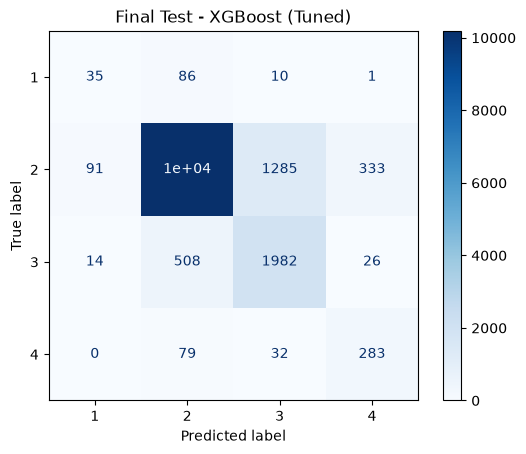

,Model,Variant,Macro F1,Weighted F1,Balanced Accuracy,Accuracy
0,XGBoost,Tuned,0.594346,0.84388,0.655797,0.835161


In [21]:
# Predict final test set
y_test_pred = final_model.predict(X_test)

# Calculate final metrics
test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)

test_balanced_acc = balanced_accuracy_score(
    y_test,
    y_test_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

# Store final results
final_test_results = pd.DataFrame([{
    "Model": champion_family,
    "Variant": champion_variant,
    "Macro F1": test_macro_f1,
    "Weighted F1": test_weighted_f1,
    "Balanced Accuracy": test_balanced_acc,
    "Accuracy": test_accuracy
}])

print("Final Test Results")
print("-" * 35)
print(f"Macro F1:          {test_macro_f1:.4f}")
print(f"Weighted F1:       {test_weighted_f1:.4f}")
print(f"Balanced Accuracy: {test_balanced_acc:.4f}")
print(f"Accuracy:          {test_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=class_labels,
        zero_division=0
    )
)

# Plot confusion matrix
test_cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_labels
)

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=class_labels
).plot(cmap="Blues")

plt.title(
    f"Final Test - {champion_family} ({champion_variant})"
)

plt.show()

final_test_results

#### temporary part (just to create a pickle file for final.ipynb file to run)

In [ ]:
# from xgboost import XGBClassifier
# from sklearn.preprocessing import LabelEncoder
# from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
# # Encode target labels before training and decode predictions afterward.

# class EncodedXGBClassifier:

#     def __init__(self, **params):
#         self.params = params

#         self.model = XGBClassifier(
#             **params
#         )

#         self.label_encoder = LabelEncoder()


#     def fit(
#         self,
#         X,
#         y,
#         sample_weight=None
#     ):

#         y_encoded = (
#             self.label_encoder
#             .fit_transform(y)
#         )

#         self.model.fit(
#             X,
#             y_encoded,
#             sample_weight=sample_weight
#         )

#         return self


#     def predict(self, X):

#         y_pred_encoded = (
#             self.model
#             .predict(X)
#             .astype(int)
#         )

#         return (
#             self.label_encoder
#             .inverse_transform(
#                 y_pred_encoded
#             )
#         )

In [ ]:
# # Combine train and validation data for final training.

# X_train_final = pd.concat(
#     [
#         X_train,
#         X_val
#     ],
#     axis=0,
#     ignore_index=True
# )

# y_train_final = pd.concat(
#     [
#         y_train,
#         y_val
#     ],
#     axis=0,
#     ignore_index=True
# )

# print(
#     "Final training shape:",
#     X_train_final.shape
# )

# print(
#     "Final training samples:",
#     len(X_train_final)
# )

Final training shape: (84816, 25)
Final training samples: 84816


In [ ]:
# # Create balanced sample weights from the final training data.

# final_sample_weights = compute_sample_weight(
#     class_weight="balanced",
#     y=y_train_final
# )

# print(
#     "Sample weights created:",
#     len(final_sample_weights)
# )

Sample weights created: 84816


In [ ]:
# # Create the final tuned XGBoost model.

# final_xgb_model = EncodedXGBClassifier(

#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=9,

#     min_child_weight=1,

#     subsample=0.7,
#     colsample_bytree=0.85,

#     gamma=0.1,

#     reg_alpha=0.1,
#     reg_lambda=1,

#     objective="multi:softprob",
#     num_class=4,

#     eval_metric="mlogloss",
#     tree_method="hist",

#     random_state=42,
#     n_jobs=-1
# )

In [28]:
# Train the final model on Train + Validation.

final_xgb_model.fit(
    X_train_final,
    y_train_final,
    sample_weight=final_sample_weights
)

print(
    "Final Tuned XGBoost trained successfully."
)

Final Tuned XGBoost trained successfully.


In [ ]:
# # Evaluate the final model on the untouched test set.

# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     f1_score,
#     classification_report
# )


# y_test_pred = final_xgb_model.predict(
#     X_test
# )


# test_macro_f1 = f1_score(
#     y_test,
#     y_test_pred,
#     average="macro"
# )

# test_weighted_f1 = f1_score(
#     y_test,
#     y_test_pred,
#     average="weighted"
# )

# test_balanced_accuracy = (
#     balanced_accuracy_score(
#         y_test,
#         y_test_pred
#     )
# )

# test_accuracy = accuracy_score(
#     y_test,
#     y_test_pred
# )


# print("Final Test Results")
# print("-" * 35)

# print(
#     f"Macro F1:          "
#     f"{test_macro_f1:.4f}"
# )

# print(
#     f"Weighted F1:       "
#     f"{test_weighted_f1:.4f}"
# )

# print(
#     f"Balanced Accuracy: "
#     f"{test_balanced_accuracy:.4f}"
# )

# print(
#     f"Accuracy:          "
#     f"{test_accuracy:.4f}"
# )

# print("\nClassification Report:")

# print(
#     classification_report(
#         y_test,
#         y_test_pred,
#         labels=[1, 2, 3, 4],
#         zero_division=0
#     )
# )

Final Test Results
-----------------------------------
Macro F1:          0.5943
Weighted F1:       0.8439
Balanced Accuracy: 0.6558
Accuracy:          0.8352

Classification Report:
              precision    recall  f1-score   support

           1       0.25      0.27      0.26       132
           2       0.94      0.86      0.90     11898
           3       0.60      0.78      0.68      2530
           4       0.44      0.72      0.55       394

    accuracy                           0.84     14954
   macro avg       0.56      0.66      0.59     14954
weighted avg       0.86      0.84      0.84     14954



In [ ]:
# # Save the final trained XGBoost model and its target classes.

# final_xgb_model.model.save_model(
#     "final_tuned_xgboost.json"
# )

# np.save(
#     "final_xgboost_classes.npy",
#     final_xgb_model.label_encoder.classes_
# )

# print(
#     "Final XGBoost model saved successfully."
# )

Final XGBoost model saved successfully.
